In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from itertools import groupby
from operator import itemgetter
from scipy.stats import spearmanr, pearsonr
import matplotlib as mpl

## Preparing data

In [3]:
# Load the data
data = pd.read_csv("Kanyapella.csv")

data['avg_temp']=(pd.to_numeric(data['max_temp'])+pd.to_numeric(data['min_temp']))/2
data['Date'] = pd.to_datetime(data['YYYY-MM-DD'], format="%d/%m/%Y")

In [4]:
Et = pd.to_numeric(data['et_morton_actual'])

# Get rainfall column
Rain = pd.to_numeric(data['daily_rain'])

# Initialize H
H = [0]

# Calculate H using the formula iteratively
for i in range(1, len(data)):
    H.append(max(0, H[i-1] + Rain[i-1] - Et[i-1]))

# Add result to DataFrame
data['H'] = H

In [5]:
# Read the data from Russell 1986
trapdata = pd.read_csv("Russell_1986_data_extraction.csv")
trapdata['Date'] = pd.to_datetime(trapdata['Date'], format="%d/%m/%Y")

## Fixed parameters

In [7]:
Gamma_Ao = 2
Gamma_Aem = 1/2.25
Gamma_Ah = 1/1
mu_em = 0.1
mu_r = 0.08
mu_A = 1/43
Kappa_L = 60000
Kappa_P = 750
sigma = 0.5
b = 150

## Temperature dependent parameters

In [9]:
def model_functions(T_values):
    results = []

    for T in T_values:
        f_E = np.maximum(-0.22584167135625277 + 0.02938619991749114 * T, 0)
        f_L = 0.06494664519945703 - 0.0052756957520204584 * T + 0.00024460680510909546 * T**2
        f_P = np.maximum(-0.30242427348916734 + 0.03185883178407586 * T, 0)
        f_Ag = np.maximum(0.012899492899468455 * T - 0.06445926946783458, 0)
        
        m_E = 4.062082185419959 - 0.303551467661088 * T + 0.005760661834651404 * T**2
        m_L = 2.6816120384385735 - 0.2059482508885142 * T + 0.00398441781782507 * T**2
        m_P = 0.41261868432678683 - 0.01768022562916091 * T + 0.0002133140318825642 * T**2
        m_A = np.maximum(-0.013134438602457221 + 0.00252921681275442 * T, mu_A)
        
        results.append((f_E, f_P, f_L, f_Ag, m_E, m_L, m_P, m_A))
        
    return results

In [10]:
T_functions = model_functions(data['avg_temp'].values)

## Summer periods

In [12]:
# Create a DataFrame with dates and temperature
df2 = pd.DataFrame({
    'Date': data['Date'],
    'T_value': data['avg_temp'].values
})

# Add day-of-year and year columns
df2['DayOfYear'] = df2['Date'].dt.dayofyear
df2['Year'] = df2['Date'].dt.year

In [13]:
def find_first_day_threshold(df, start_month_day, threshold, n_days, above=True):
    results = []

    for year in df['Year'].unique():
        try:
            start_date = datetime(year, start_month_day[0], start_month_day[1])
        except ValueError:
            continue  # Skip invalid dates like Feb 29 in a non-leap year

        df_year = df[(df['Date'] >= start_date) & (df['Date'].dt.year <= year + 1)].copy()
        df_year = df_year.sort_values('Date').reset_index(drop=True)

        for i in range(n_days - 1, len(df_year)):
            window = df_year.iloc[i - n_days + 1:i + 1]
            avg = window['T_value'].mean()

            if (above and avg > threshold) or (not above and avg < threshold):
                results.append({
                    'Year': year,
                    'Date': df_year.iloc[i]['Date'],
                    'n_day_avg': avg
                })
                break

    return pd.DataFrame(results)

In [14]:
def summer_period(df, spring_start_date, summer_end_date, threshold, n_days, force_first=True):
    starts = find_first_day_threshold(df, spring_start_date, threshold=threshold, n_days=n_days, above=True)
    ends = find_first_day_threshold(df, summer_end_date, threshold=threshold, n_days=n_days, above=False)

    summer_periods = []

    # Forced first period but starts part way through so removed later
    if force_first:
        first_valid_end = ends[ends['Date'] > df['Date'].iloc[0]]
        if not first_valid_end.empty:
            end_date = first_valid_end.iloc[0]['Date'] - timedelta(days=1)
            summer_periods.append((df['Date'].iloc[0], end_date))
    else:
        # Check actual n-day average at start
        initial_window = df.iloc[:n_days]
        if len(initial_window) == n_days:
            initial_avg = initial_window['T_value'].mean()
            if initial_avg > threshold:
                first_end = ends[ends['Date'] > df['Date'].iloc[0]]
                if not first_end.empty:
                    end_date = first_end.iloc[0]['Date'] - timedelta(days=1)
                    summer_periods.append((df['Date'].iloc[0], end_date))

    # 🔹 Continue with regular start/end pairing
    for i in range(len(starts)):
        spring_date = starts.loc[i, "Date"]
        year = starts.loc[i, "Year"]

        summer_row = ends[ends["Year"] == year + 1]
        if not summer_row.empty:
            summer_date = summer_row.iloc[0]["Date"] - timedelta(days=1)
            summer_periods.append((spring_date, summer_date))

    return summer_periods

In [15]:
summer_periods = summer_period(df2, (9, 1), (3, 1), threshold=17.5, n_days=4, force_first=True)[1:]

In [16]:
H_results = []

for start, end in summer_periods:
    H_sum = data.loc[(data['Date'] >= start) & (data['Date'] <= end), 'H'].sum()
    H_results.append({
        'Start': start,
        'End': end,
        'Days': (end - start).days + 1, # Inclusive end date
        'H_sum': H_sum,
        'H_avg': H_sum/((end - start).days + 1)
    })

period_H = pd.DataFrame(H_results)

In [17]:
# Convert Start and End columns in periods to datetime
period_H['Start'] = pd.to_datetime(period_H['Start'])
period_H['End'] = pd.to_datetime(period_H['End'])

# Initialize a new column in data to hold H_avg
data['H_avg'] = pd.NA

# For each period, assign the period's H_avg to rows in data where date is within that period
for idx, period in period_H.iterrows():
    mask = (data['Date'] >= period['Start']) & (data['Date'] <= pd.Timestamp(year=period['End'].year, month=7, day=1))
    data.loc[mask, 'H_avg'] = period['H_avg']

data['H_avg'] = pd.to_numeric(data['H_avg'], errors='coerce')

In [18]:
# Creating flags for summer period or winter period
data['summer_period'] = False

for start, end in summer_periods:
    mask = (data['Date'] >= start) & (data['Date'] <= end)
    data.loc[mask, 'summer_period'] = True

## Defining model

In [20]:
def euler_step(t, y, dt, params, T_functions, H_values, is_summer_period, period_reset_flag, start_year=1978):
    # Unpack fixed parameters
    Gamma_Aem, Gamma_Ao, Gamma_Ah, mu_em, mu_r, mu_A, Kappa_L, Kappa_P, sigma, b, threshold = params
    
    # Unpack the state variables
    E = y[0]; L = y[1]; P = y[2]; A_em = y[3]
    A_h = y[4]; A_g = y[5]; A_o = y[6]; A_d = y[7]
    
    # Determine the total number of days
    total_days = int(t)
    # Use average water balance
    H = H_values[total_days]
    
    # Unpack temperature-dependent parameters
    f_E, f_P, f_L, f_Ag, m_E, m_L, m_P, m_A = T_functions[total_days]
    
    is_summer_period = summer_flags[total_days]

    if not np.isnan(H) and H < threshold:
        Kappa_P /= 10
        Kappa_L /= 10

    # Calculate derivativens
    if is_summer_period:
        if not period_reset_flag:
            E = 0
            L = 0
            P = 0
            A_em = 0
            A_h = 0
            A_g = 0
            A_o = 0
            period_reset_flag = True
        phi = 0
        Gamma_Ad = 1/dt
    else:
        phi = 1
        Gamma_Ad = 0
        period_reset_flag = False

    dE = Gamma_Ao * b * A_o - (m_E + f_E) * E
    dL = f_E * E - (m_L * (1 + L / Kappa_L) + f_L) * L
    dP = f_L * L - (m_P + f_P) * P
    dA_em = f_P * P * sigma * np.exp(-mu_em * (1 + P / Kappa_P)) - (m_A + Gamma_Aem) * A_em
    dA_h = Gamma_Aem * A_em + (1 - phi) * Gamma_Ao * A_o + Gamma_Ad * A_d - (m_A + mu_r + Gamma_Ah) * A_h
    dA_g = Gamma_Ah * A_h - (m_A + f_Ag) * A_g
    dA_o = f_Ag * A_g - (m_A + mu_r + Gamma_Ao) * A_o
    dA_d = phi * Gamma_Ao * A_o - Gamma_Ad * A_d - mu_A * A_d  
    
    # Return updated state variables after one Euler step
    y_new = [
        E + dE * dt,
        L + dL * dt,
        P + dP * dt,
        A_em + dA_em * dt,
        A_h + dA_h * dt,
        A_g + dA_g * dt,
        A_o + dA_o * dt,
        A_d + dA_d * dt,
    ]
    
    return y_new, period_reset_flag

## Running model

In [22]:
# Initial conditions
E_ini = 0  # Initial number of eggs
L_ini = 0      # Initial number of larvae
P_ini = 0      # Initial number of pupae
A_em_ini = 0   # Initial number of emerging adults
A_h_ini = 1000   # Initial number of females searching for hosts
A_g_ini = 0   # Initial number of females resting after feeding
A_o_ini = 0   # Initial number of females searching for oviposition sites
A_d_ini = 0   # Initial number of diapausing parous adults


# Initial state vector
y_init = [E_ini, L_ini, P_ini, A_em_ini, A_h_ini, A_g_ini, A_o_ini, A_d_ini]

# Set initial values
period_reset_flag = True # True if starting in summer period, false if in winter
summer_flags = data['summer_period'].values
H_values = data['H_avg'].values
threshold =  13.710067555711506

# Time settings
dt = 0.05  # Time step (in days)
t_max = len(data['avg_temp']) # Total time
time_points = np.arange(0, t_max, dt)

results = np.empty((len(time_points[::20]), len(y_init)))

# Initialize parameters (set to appropriate values)
params = [
    Gamma_Aem, Gamma_Ao, Gamma_Ah, mu_em, mu_r, mu_A, Kappa_L, Kappa_P, sigma, b, threshold
]

# Run the model using Euler method
y = y_init
for i, t in enumerate(time_points):
    y, period_reset_flag = euler_step(t, y, dt, params, T_functions, H_values, summer_flags, period_reset_flag)
    if i % 20 == 19:
        results[i // 20] = y

In [23]:
E = results[:,0]
L = results[:,1]
P = results[:,2]
A_em = results[:,3]
A_h = results[:,4]
A_g = results[:,5]
A_o = results[:,6]
A_d = results[:,7]

## Performing correlation with Russell trapping data and host-seeking adults in model

In [25]:
# Create DataFrame for A_h
df_Ah = pd.DataFrame({
    'Date': data['Date'],
    'A_h': A_h 
})

### Model output correlation

In [27]:
# Merge mosquito numbers data with A_h data on 'Date'
merged_trap_model = pd.merge(df_Ah, trapdata, on='Date', how='inner')

In [28]:
# Metrics
r, p_p = pearsonr(merged_trap_model['mosquito_numbers'], merged_trap_model['A_h'])
rho, p_s = spearmanr(merged_trap_model['mosquito_numbers'], merged_trap_model['A_h'])

# Assign significance stars
if p_p < 0.001:
    stars = '***'
elif p_p < 0.01:
    stars = '**'
elif p_p < 0.05:
    stars = '*'
else:
    stars = ''

# Assign significance stars
if p_s < 0.001:
    stars = '***'
elif p_s < 0.01:
    stars = '**'
elif p_s < 0.05:
    stars = '*'
else:
    stars = ''

# Errors
mse = np.mean((merged_trap_model['mosquito_numbers'] - merged_trap_model['A_h'])**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(merged_trap_model['mosquito_numbers'] - merged_trap_model['A_h']))
mbe = np.mean(merged_trap_model['A_h'] - merged_trap_model['mosquito_numbers'])
    
print(f"Pearson r = {r:.3f}{stars} (p = {p_p:.3e})")
print(f"Spearman ρ = {rho:.3f}{stars} (p = {p_s:.3e})")
print(f"RMSE = {rmse:.3f}")
print(f"MAE = {mae:.3f}")
print(f"MBE = {mbe:.3f}")

Pearson r = 0.596*** (p = 3.548e-10)
Spearman ρ = 0.580*** (p = 1.380e-09)
RMSE = 253.037
MAE = 148.536
MBE = 84.266


## Plotting model output and field data

In [30]:
# Total days from September 1, 1979, to April 30, 1985
A_h_adjusted = A_h[243+365:]

# Relevant date range
dates_adjusted = np.arange(np.datetime64('1979-09-01'), np.datetime64('1985-05-01'))

# Shading same length
summer_flags_adjusted = summer_flags[243+365:]

In [31]:
mpl.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 10,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,

    # Axis lines
    "axes.linewidth": 0.5,

    # Tick thickness
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,

    # Tick length (optional but helpful)
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Line plots
    "lines.linewidth": 1,

    # Fonts
    "font.family": "Arial",

    # PDF export
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

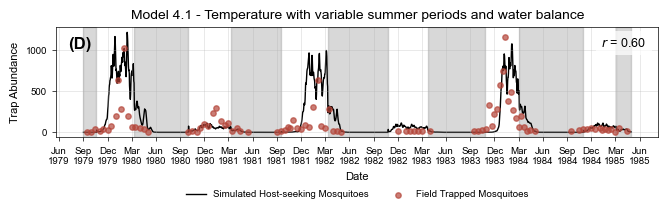

In [32]:
# Plot setup
plt.figure(figsize=(170/25.4, 2))

# Subplot for Mosquito Numbers and A_h
ax1 = plt.subplot(1, 1, 1)
ax1.plot(dates_adjusted[:2069], A_h_adjusted, label='Simulated Host-seeking Mosquitoes', color='black', zorder=1)
ax1.scatter(merged_trap_model['Date'], merged_trap_model['mosquito_numbers'], color='#B4463A', alpha=0.7, s=15, zorder=2, label='Field Trapped Mosquitoes')
ax1.set_title('Model 4.1 - Temperature with variable summer periods and water balance')
ax1.set_xlabel('Date')
ax1.set_ylabel('Trap Abundance')
ax1.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.4),
    ncol=2,
    frameon=False
)
ax1.grid(True, linewidth = 0.4, alpha = 0.5)
# Set major ticks to every 3 months — Dec, Mar, Jun, Sep
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[12, 3, 6, 9]))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax1.tick_params(axis='both')

# Shade winter periods
winter_indexes = [i for i, f in enumerate(summer_flags_adjusted[:2069]) if not f]
for k, g in groupby(enumerate(winter_indexes), lambda ix: ix[0] - ix[1]):
    group = list(map(itemgetter(1), g)) 
    start_date = dates_adjusted[group[0]]
    end_date = dates_adjusted[group[-1]]
    ax1.axvspan(start_date, end_date, color="grey", alpha=0.3, zorder=0)

# Add Pearson's r text
ax1.text(
    0.98, 0.92,
    fr'$r$ = {r:.2f}',
    transform=ax1.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
)

# Add panel label (D) in bold in the top left
ax1.text(
    0.02, 0.92,
    '(D)', 
    transform=ax1.transAxes,
    fontsize=12,
    fontweight='bold',
    verticalalignment='top',
    horizontalalignment='left'
)

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.88,
    bottom=0.33
)

# Show the plot
plt.show()